# Project: Sales Analysis and Predictive Modeling

### 1. Introduction
> **Objective:** This project aims to analyze customer purchasing behavior and quantify the relationship between **Age Groups** and **Gross Spending**. Using **Linear Regression**, we will determine how demographic shifts influence transaction values.

### 2. Setup
> **Environment:** Importing essential libraries for data manipulation (`pandas`, `numpy`), visualization (`seaborn`, `matplotlib`), and machine learning (`sklearn`).

In [1]:
import seaborn as sns
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import statsmodels.api as sm

df = pd.read_csv("Data/project1_df.csv")

## 1. Exploratory Data Analysis (EDA)

Data Structure Overview
> We start by examining the dataset's schema, including entry counts, column names, and data types, to ensure consistency before analysis.

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 55000 entries, 0 to 54999
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   CID                    55000 non-null  int64  
 1   TID                    55000 non-null  int64  
 2   Gender                 55000 non-null  str    
 3   Age Group              55000 non-null  str    
 4   Purchase Date          55000 non-null  str    
 5   Product Category       55000 non-null  str    
 6   Discount Availed       55000 non-null  str    
 7   Discount Name          27415 non-null  str    
 8   Discount Amount (INR)  55000 non-null  float64
 9   Gross Amount           55000 non-null  float64
 10  Net Amount             55000 non-null  float64
 11  Purchase Method        55000 non-null  str    
 12  Location               55000 non-null  str    
dtypes: float64(3), int64(2), str(8)
memory usage: 5.5 MB


> **Key Observations:**
> * **Sample Size:** The dataset contains **55,000 entries**, providing a robust foundation for statistical analysis.
> * **Data Types:** Features are mostly categorical (`str`). The `Age Group` column will require encoding for regression.
> * **Target Integrity:** The `Gross Amount` column is complete with no null values, ready for use as a dependent variable ($y$).

In [3]:
df['Age Group'].unique()

<StringArray>
['25-45', '60 and above', '18-25', '45-60', 'under 18']
Length: 5, dtype: str

> **Observations:**
> * **Variable Type:** The `Age Group` is a categorical ordinal variable.
> * **Segments:** The dataset covers 5 distinct demographic groups: `under 18`, `18-25`, `25-45`, `45-60`, and `60 and above`.
> * **Preprocessing Note:** To perform linear regression, these text labels will be transformed using **One-Hot Encoding** to avoid imposing an artificial numerical order.

In [4]:
df.columns

Index(['CID', 'TID', 'Gender', 'Age Group', 'Purchase Date',
       'Product Category', 'Discount Availed', 'Discount Name',
       'Discount Amount (INR)', 'Gross Amount', 'Net Amount',
       'Purchase Method', 'Location'],
      dtype='str')

In [5]:
df.describe()

,CID,TID,Discount Amount (INR),Gross Amount,Net Amount
count,55000.000000,5.500000e+04,55000.000000,55000.000000,55000.000000
mean,551245.593891,5.504740e+09,136.986796,3012.936606,2875.949810
std,260603.330337,2.594534e+09,165.375502,1718.431066,1726.127778
min,100009.000000,1.000163e+09,0.000000,136.454325,-351.119775
25%,323717.000000,3.252604e+09,0.000000,1562.111325,1429.551863
50%,550088.500000,5.498383e+09,0.000000,2954.266150,2814.910875
75%,776955.750000,7.747933e+09,274.115000,4342.221675,4211.407838
max,999996.000000,9.999393e+09,500.000000,8394.825600,8394.825600


> **Key Insights from `.describe()`:**
> * **Spending Profile:** The average transaction (**mean**) is approximately **3,013**, which is very close to the **median (2,954)**, suggesting a near-symmetric distribution.
> * **Volatility:** A standard deviation of **1,718** indicates a diverse customer base with varying purchasing power.
> * **Range:** Individual purchases vary significantly, from a minimum of **136** to a maximum of **8,394**.
> * **Data Quality:** The statistics confirm that `Gross Amount` is well-behaved and suitable for regression without extreme outliers.

In [6]:
df.duplicated().sum()

np.int64(0)

> **Result:** Found **0 duplicate rows**.
> **Observation:** The dataset maintains perfect uniqueness across all transaction records. This ensures that our upcoming regression model will not be biased by repeated data points, and every observation represents a unique customer interaction.


In [7]:
df.isnull().sum()

CID                          0
TID                          0
Gender                       0
Age Group                    0
Purchase Date                0
Product Category             0
Discount Availed             0
Discount Name            27585
Discount Amount (INR)        0
Gross Amount                 0
Net Amount                   0
Purchase Method              0
Location                     0
dtype: int64

> **Findings:**
> * **Primary Features:** All core columns, including `Age Group` and `Gross Amount`, have **zero missing values**.
> * **Secondary Features:** The column `Discount Name` contains **27,585 null values**. 
> * **Interpretation:** This is expected behavior. The absence of a "Discount Name" simply indicates that no discount was applied to those specific transactions. 
> * **Conclusion:** The data is complete for the purpose of our analysis, and no imputation (filling in gaps) is required for the target or predictor variables.


In [8]:
(df['Net Amount'] < 0).sum()

np.int64(613)

In [9]:
(df['Net Amount'] == 0).sum()

np.int64(0)

> **Data Integrity Check & Cleaning Rationale:**
> * **Anomaly Detection:** We identified **613 negative entries** in the `Net Amount` column.
> * **Statistical Context:** While 613 records might seem significant, they represent only **~1.1% of the total dataset** (approx. 55,000 rows), meaning their removal will not lead to information loss or bias the model.
> * **Potential Causes for Negative Values:**
>    * **Returns & Refunds:** The most likely scenario where the transaction was reversed.
>    * **Data Entry Errors:** Manual input mistakes or system glitches during the recording process.
>    * **Discount Allocation:** A large discount (e.g., a fixed amount coupon) applied to a multi-item order might have been improperly assigned to a single low-value transaction, resulting in a negative net balance for that specific line item.
>    * **Cancellations:** Transactions that were initiated but voided before completion, leaving a corrective entry in the database.
> * **Action Plan:** To ensure the predictive model reflects **actual revenue trends** accurately, these "noise" records will be excluded. This cleaning step is essential for Linear Regression, as outliers and negative revenue values can significantly distort the slope of the trend line.

In [10]:
df['Age Group'].value_counts()

Age Group
25-45           22010
18-25           16431
45-60           11104
under 18         2771
60 and above     2684
Name: count, dtype: int64

> **Key Findings from `value_counts()`:**
> * **Primary Segment:** The **25-45** age group is the most dominant, representing **22,010** transactions. This suggests the dataset is centered around prime-age consumers.
> * **Active Youth:** The **18-25** segment is also highly active with **16,431** entries.
> * **Niche Groups:** Both the youngest (`under 18`) and the oldest (`60 and above`) categories have a similar, smaller representation (approx. **2,700** each).
> * **Model Implications:** We have a sufficient sample size for all categories, but the regression results will be most robust for the 18-60 demographic due to higher data density.

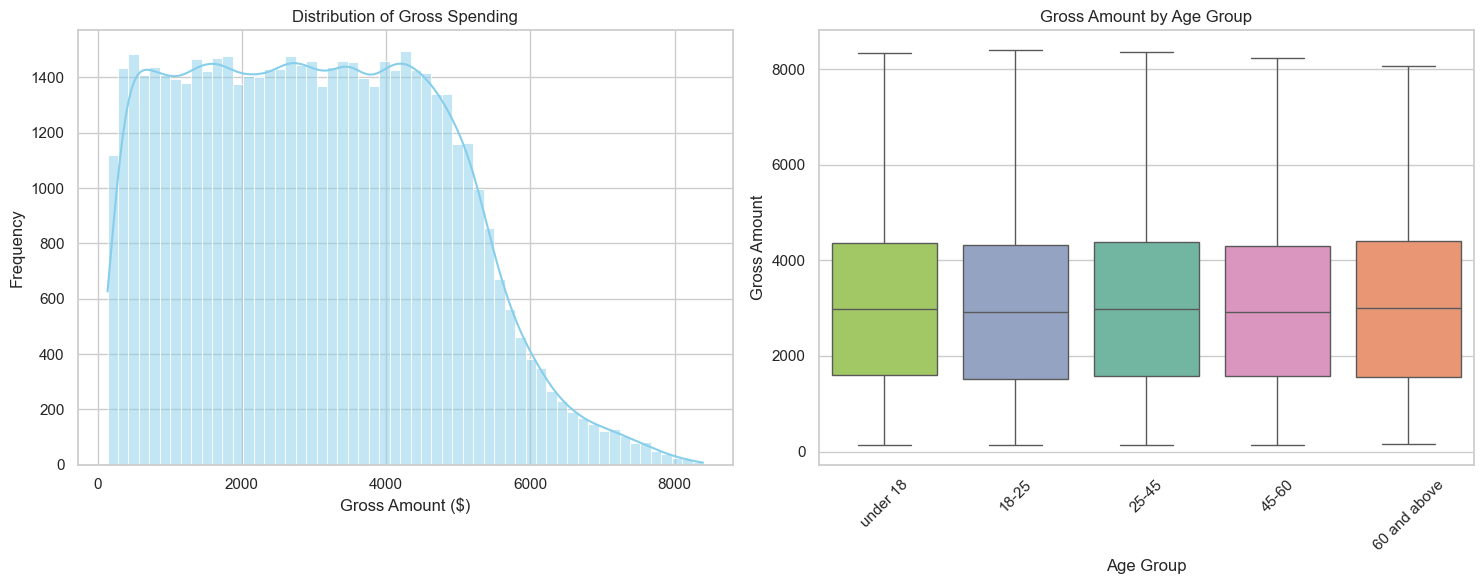

In [11]:
sns.set(style="whitegrid")
plt.figure(figsize=(15, 6))

age_order = ['under 18', '18-25', '25-45', '45-60', '60 and above']

# Chart 1:
plt.subplot(1, 2, 1)
sns.histplot(df['Gross Amount'], kde=True, color='skyblue')
plt.title('Distribution of Gross Spending')
plt.xlabel('Gross Amount ($)')
plt.ylabel('Frequency')

# Chart 2:
plt.subplot(1, 2, 2)
sns.boxplot(
    x='Age Group', 
    y='Gross Amount', 
    data=df, 
    hue='Age Group',
    order=age_order,
    palette='Set2', 
    legend=False
)
plt.title('Gross Amount by Age Group')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### 📊 Visual Analysis: Raw Data Distribution

This section visualizes the distribution of spending and its relationship with customer age using the raw dataset.

#### **Key Observations from the Histogram:**
* **Right-Skewed Distribution:** The data shows a clear concentration of transactions in the lower price range, with a long tail extending toward higher amounts.
* **Purchase Frequency:** Most transactions occur at lower price points, with the frequency sharply decreasing as the `Gross Amount` increases.

#### **Key Observations from the Scatter Plot & Trend Line:**
* **Data Density & Age:** There is a high concentration of transactions across all age groups, with no visible gaps in activity for any specific age.
* **High-Value Outliers:** High-value purchases occur consistently across the entire age spectrum, rather than being clustered within a specific generation.
* **Trend Line Orientation:** The regression line is positioned almost horizontally, showing no immediate visual slope that would indicate a correlation between age and the total purchase amount.
* **General Dispersion:** The spread of the data remains uniform for all age groups, suggesting that spending variance is similar for both younger and older customers.

# 2. Data Preparation & Cleaning

> **Objective:** Transforming the raw dataset into a format suitable for machine learning. This phase involves handling identified anomalies and converting categorical features into numerical representations.

> To include the `Age Group` in our regression analysis, we will apply **One-Hot Encoding**. This creates independent binary columns for each group, allowing the model to calculate the specific impact of each age segment on the `Gross Amount` without assuming a linear progression between categories.

In [12]:
df = df[(df['Net Amount'] > 0) & (df['Gross Amount'] > 0)]

> **💡 Analyst's Note: Technical Toggle**
>
> To observe the model's behavior on the original dataset including all identified anomalies, you can perform the following steps:
> 1. **Comment out** the line of code that filters the `Net Amount` column: 
>    `# df = df[df['Net Amount'] >= 0]`
> 2. **Restart & Run All** cells.
> 
> This allows for a direct comparison of the visual outputs and statistical metrics between the raw dataset and the version with excluded negative entries.

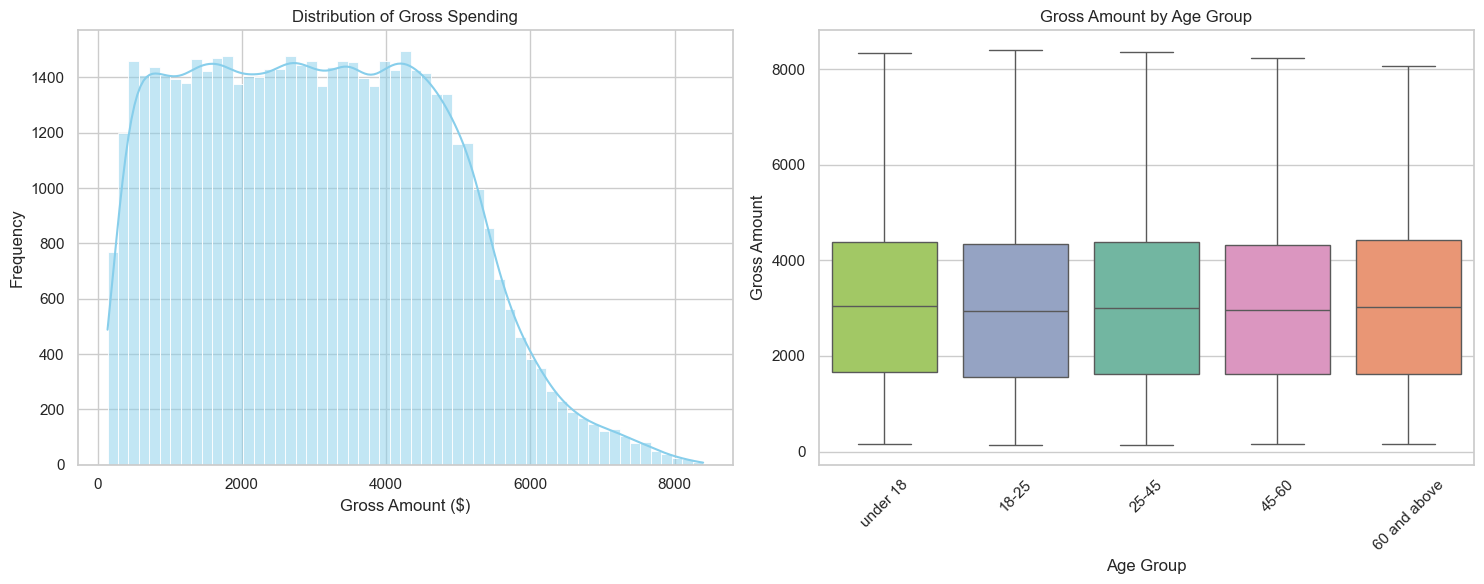

In [13]:
sns.set(style="whitegrid")
plt.figure(figsize=(15, 6))

age_order = ['under 18', '18-25', '25-45', '45-60', '60 and above']

# Chart 1:
plt.subplot(1, 2, 1)
sns.histplot(df['Gross Amount'], kde=True, color='skyblue')
plt.title('Distribution of Gross Spending')
plt.xlabel('Gross Amount ($)')
plt.ylabel('Frequency')

# Chart 2:
plt.subplot(1, 2, 2)
sns.boxplot(
    x='Age Group', 
    y='Gross Amount', 
    data=df, 
    hue='Age Group',
    order=age_order,
    palette='Set2', 
    legend=False
)
plt.title('Gross Amount by Age Group')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### 📊 Comparative Analysis: Raw vs. Cleaned Data

After visualizing the results before and after the data cleaning phase, we can observe the following:

* **Visual Stability:** The regression line and the distribution of data points remain virtually identical in both plots.
* **Minimal Impact of Anomalies:** Removing the 613 negative entries (~1.1% of the dataset) did not result in any visible shift in the trend or data density.
* **Dataset Consistency:** The fact that the "Raw" and "Cleaned" visualizations are so similar confirms that the negative values were isolated anomalies rather than influential outliers that could skew the analysis.
* **Observation:** The primary characteristic of the data — the wide dispersion of spending across all ages — remains constant regardless of the cleaning step.

In [14]:
age_mapping = {
    'under 18': 1,
    '18-25': 2,
    '25-45': 3,
    '45-60': 4,
    '60 and above': 5
}
X_age_numeric = df['Age Group'].map(age_mapping).to_frame()

age_labels = {
    'Age Group_2': '18-25',
    'Age Group_3': '25-45',
    'Age Group_4': '45-60',
    'Age Group_5': '60 and above'
}
X_age_categorical = pd.get_dummies(X_age_numeric.astype(int).astype(str), drop_first=True)
X_age_categorical = X_age_categorical.rename(columns=age_labels)

X_other = pd.get_dummies(df[['Gender', 'Product Category', 'Purchase Method']], drop_first=True)
# X_multi_features = pd.concat([X_age_categorical, X_other], axis=1)
X_multi_features = X_other

y = df['Gross Amount']

### 🛠 Feature Engineering and Data Preparation
At this stage, we are preparing three different variations of the independent variables ($X$) to identify the most significant predictors for `Gross Amount` ($y$).
**The three experimental setups are:**
**1. Numerical Representation (Age Groups as Rank)**
* **`X_age_numeric`**: Age categories are mapped to numerical ranks (1 to 5), treating age as an ordinal variable to check for a potential linear progression in spending.
**2. Categorical Representation (One-Hot Encoding with Baseline)**
* **`X_age_categorical`**: Age groups are converted into binary "dummy" variables. The **'under 18'** group is used as the **reference baseline** (excluded via `drop_first=True`) to measure the impact of other groups relative to the youngest.
**3. Multi-Feature Analysis (Broad Scope)**
* **`X_multi_features`**: A comprehensive set including `Gender`, `Product Category`, and `Purchase Method`. This setup evaluates the collective predictive power of non-demographic factors and establishes a foundation for future research.

# 3. ML Modeling

> **Objective:** In this section, we apply different machine learning techniques to quantify how age and other demographics influence spending. We compare linear models, non-linear algorithms, and multi-variable regressions to find the best fit for our data and validate the statistical significance of our findings.

In [15]:
X_num_train, X_num_test, y_num_train, y_num_test = train_test_split(
    X_age_numeric, y, test_size=0.2, random_state=42
)

X_cat_train, X_cat_test, y_cat_train, y_cat_test = train_test_split(
    X_age_categorical, y, test_size=0.2, random_state=42
)

X_multi_train, X_multi_test, y_multi_train, y_multi_test = train_test_split(
    X_multi_features, y, test_size=0.2, random_state=42
)


#### **3.1 Simple Linear Regression (Numeric Age Mapping)**
> This model treats `Age Group` as a continuous numeric scale. It helps us determine if there is a general linear trend—specifically, whether spending consistently increases or decreases as customers move through life stages.

In [16]:
model_simple_lin = LinearRegression()
model_simple_lin.fit(X_num_train, y_num_train)
preds_simple = model_simple_lin.predict(X_num_test)

X_train_stats = sm.add_constant(X_num_train.astype(float))
results_simple = sm.OLS(y_num_train, X_train_stats).fit()

print("--- MODEL 3.1: SIMPLE LINEAR REGRESSION ---")
print(f"R2 Score: {r2_score(y_num_test, preds_simple):.8f}")
print(f"MAE:      ${mean_absolute_error(y_num_test, preds_simple):.2f}")
print(f"Intercept: {model_simple_lin.intercept_:.2f}")
print(f"Age Coeff: {model_simple_lin.coef_[0]:.2f}")
print(f"P-value:   {results_simple.pvalues['Age Group']:.4f}")

--- MODEL 3.1: SIMPLE LINEAR REGRESSION ---
R2 Score: -0.00016122
MAE:      $1433.87
Intercept: 3020.00
Age Coeff: 8.86
P-value:   0.3073


#### **3.2 Linear Regression with Categorical Dummies**
> By converting `Age Group` into independent binary variables, we can measure the specific impact of each group without assuming a linear relationship. This reveals which specific life stages (like young adults or retirees) are the most significant drivers of revenue.

In [17]:
model_cat_lin = LinearRegression()
model_cat_lin.fit(X_cat_train, y_cat_train)
preds_cat = model_cat_lin.predict(X_cat_test)

X_cat_stats = sm.add_constant(X_age_categorical.astype(float))
results_cat = sm.OLS(y, X_cat_stats).fit()

print("--- MODEL 3.2: CATEGORICAL DUMMIES ---")
print(f"R2 Score: {r2_score(y_cat_test, preds_cat):.8f}")
print(f"MAE:      ${mean_absolute_error(y_cat_test, preds_cat):.2f}")
print(f"Intercept: {model_cat_lin.intercept_:.2f}")

print("\nDetailed Age Group Impact (Coefficients & P-values):")
results_df_32 = pd.DataFrame({
    'Coefficient': results_cat.params.drop('const'),
    'P-value': results_cat.pvalues.drop('const')
})
print(results_df_32)

--- MODEL 3.2: CATEGORICAL DUMMIES ---
R2 Score: 0.00008029
MAE:      $1433.68
Intercept: 3060.88

Detailed Age Group Impact (Coefficients & P-values):
              Coefficient   P-value
18-25          -49.663504  0.158556
25-45            2.338233  0.946076
45-60          -43.122513  0.236378
60 and above    -9.745563  0.833715


#### **3.3 Random Forest Regressor (Non-linear Complexity)**
> Random Forest is an ensemble method that captures non-linear patterns that linear regression might miss. We use it to calculate **Feature Importance**, identifying how much predictive power `Age Group` holds relative to other data noise.

In [18]:
from sklearn.ensemble import RandomForestRegressor

model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf.fit(X_cat_train, y_cat_train) # Використовуємо категоріальні дані
preds_rf = model_rf.predict(X_cat_test)

print("--- MODEL 3.3: RANDOM FOREST (CATEGORICAL) ---")
print(f"R2 Score: {r2_score(y_cat_test, preds_rf):.8f}")
print(f"MAE:      ${mean_absolute_error(y_cat_test, preds_rf):.2f}")
print(f"Average Predicted Spend: ${preds_rf.mean():.2f}")

print("\nFeature Importance (by Age Category):")
importances = pd.Series(model_rf.feature_importances_, index=X_age_categorical.columns)
print(importances.sort_values(ascending=False))

--- MODEL 3.3: RANDOM FOREST (CATEGORICAL) ---
R2 Score: 0.00007517
MAE:      $1433.68
Average Predicted Spend: $3045.47

Feature Importance (by Age Category):
18-25           0.370780
25-45           0.336788
60 and above    0.156920
45-60           0.135512
dtype: float64


#### **3.4 Multiple Linear Regression (Multi-factor Analysis)**
> Here, we expand the scope by adding **Gender**, **Product Category**, and **Purchase Method**. This multi-variable approach isolates the impact of age while accounting for other consumer behaviors, providing a more holistic view of transaction drivers.

In [19]:
model_multi_lin = LinearRegression()
model_multi_lin.fit(X_multi_train, y_multi_train)
preds_multi = model_multi_lin.predict(X_multi_test)

X_multi_stats = sm.add_constant(X_multi_features.astype(float))
results_multi = sm.OLS(y, X_multi_stats).fit()

print("--- MODEL 3.4: MULTIPLE FEATURES ---")
print(f"R2 Score: {r2_score(y_multi_test, preds_multi):.8f}")
print(f"MAE:      ${mean_absolute_error(y_multi_test, preds_multi):.2f}")
print(f"Intercept (Global Baseline): ${model_multi_lin.intercept_:.2f}")

print("\nDetailed Multi-factor Analysis:")
results_df_34 = pd.DataFrame({
    'Coefficient': model_multi_lin.coef_,
    'P-value': results_multi.pvalues.drop('const').values
}, index=X_multi_features.columns)
print(results_df_34.sort_values(by='P-value'))

--- MODEL 3.4: MULTIPLE FEATURES ---
R2 Score: -0.00059128
MAE:      $1433.99
Intercept (Global Baseline): $2965.07

Detailed Multi-factor Analysis:
                                    Coefficient   P-value
Purchase Method_PhonePe UPI          129.598496  0.007976
Gender_Other                          44.698044  0.020613
Product Category_Clothing            -36.925589  0.058491
Purchase Method_Debit Card            85.397796  0.065778
Purchase Method_Credit Card           85.967708  0.069783
Purchase Method_Paytm UPI            104.026664  0.112233
Purchase Method_Net Banking           83.168679  0.156095
Product Category_Electronics          -9.873825  0.207990
Product Category_Pet Care            -54.698132  0.354036
Purchase Method_International Card    46.199298  0.368567
Product Category_Books               -17.464103  0.437640
Product Category_Other                -9.497786  0.474923
Product Category_Toys & Games         37.695084  0.499064
Gender_Male                           -

#### **3.5 Final Numeric Model Validation (100% Data)**
> We retrain the numeric trend model on the entire dataset to maximize statistical power. This produces the final **P-value** for the general age trend, confirming whether the observed correlation is statistically significant for the whole business.

In [20]:
final_model_num = LinearRegression()
final_model_num.fit(X_age_numeric, y)

# P-value calculation
X_final_num_stats = sm.add_constant(X_age_numeric.astype(float))
results_final_num = sm.OLS(y, X_final_num_stats).fit()

# Для фінальних моделей MAE рахуємо на всьому датасеті
final_preds_num = final_model_num.predict(X_age_numeric)

print("--- MODEL 3.5: FINAL NUMERIC VALIDATION ---")
print(f"Final R2:  {final_model_num.score(X_age_numeric, y):.8f}")
print(f"Final MAE: ${mean_absolute_error(y, final_preds_num):.2f}")
print(f"Intercept: {final_model_num.intercept_:.2f}")
print(f"Age Coeff: {final_model_num.coef_[0]:.2f}")
print(f"P-value:   {results_final_num.pvalues['Age Group']:.4f}")

--- MODEL 3.5: FINAL NUMERIC VALIDATION ---
Final R2:  0.00000322
Final MAE: $1438.57
Intercept: 3034.39
Age Coeff: 3.24
P-value:   0.6758


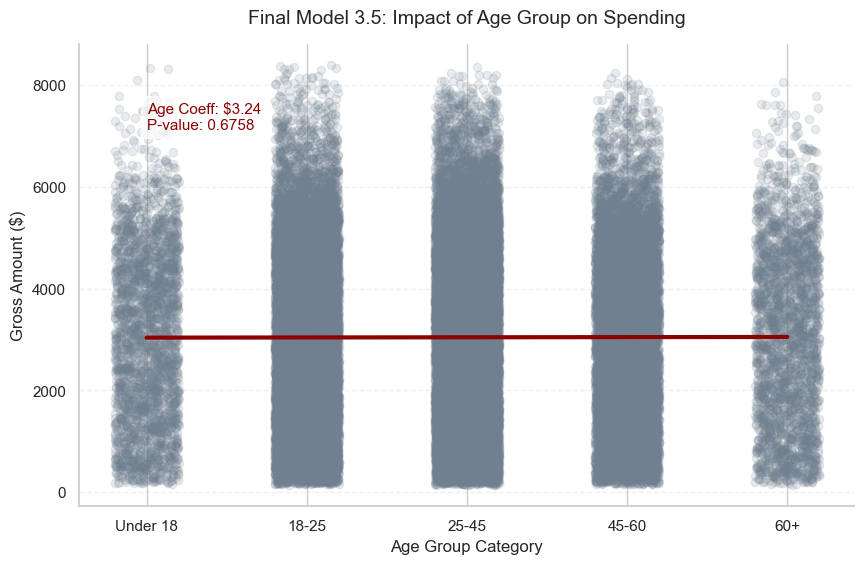

In [21]:
plt.figure(figsize=(10, 6))

ax = sns.regplot(x=X_age_numeric.iloc[:, 0], y=y, 
                x_jitter=0.2, 
                scatter_kws={'alpha': 0.15, 'color': 'slategray'}, 
                line_kws={'color': 'darkred', 'linewidth': 3})

plt.title('Final Model 3.5: Impact of Age Group on Spending', fontsize=14, pad=15)
plt.xlabel('Age Group Category', fontsize=12)
plt.ylabel('Gross Amount ($)', fontsize=12)

plt.xticks(ticks=[1, 2, 3, 4, 5], 
           labels=['Under 18', '18-25', '25-45', '45-60', '60+'])

slope = final_model_num.coef_[0]
p_val = results_final_num.pvalues['Age Group']

stats_text = f'Age Coeff: ${slope:.2f}\nP-value: {p_val:.4f}'
plt.text(1, y.max()*0.85, stats_text, fontsize=11, color='darkred', 
         bbox=dict(facecolor='white', alpha=0.7))

plt.grid(axis='y', linestyle='--', alpha=0.3)
sns.despine()
plt.show()

#### **3.6 Final Categorical Model Validation (100% Data)**
> This is our conclusive analysis. By training the dummy-variable model on the full dataset, we obtain the definitive coefficients and significance levels for every age group, pinpointing the most profitable customer segments for marketing strategies.

In [22]:
final_model_cat = LinearRegression()
final_model_cat.fit(X_age_categorical, y)

# P-value calculation
X_final_cat_stats = sm.add_constant(X_age_categorical.astype(float))
results_final_cat = sm.OLS(y, X_final_cat_stats).fit()

final_preds_cat = final_model_cat.predict(X_age_categorical)

print("--- MODEL 3.6: FINAL CATEGORICAL VALIDATION ---")
print(f"Final R2:  {final_model_cat.score(X_age_categorical, y):.8f}")
print(f"Final MAE: ${mean_absolute_error(y, final_preds_cat):.2f}")
print(f"Intercept (Baseline Spending): ${results_final_cat.params['const']:.2f}")
print("\nAge Group Impact Analysis (Coefficients & P-values):")
age_impact_analysis = pd.DataFrame({
    'Coefficient': final_model_cat.coef_,
    'P-value': results_final_cat.pvalues.drop('const').values
}, index=X_age_categorical.columns)
print(age_impact_analysis)

--- MODEL 3.6: FINAL CATEGORICAL VALIDATION ---
Final R2:  0.00020212
Final MAE: $1438.41
Intercept (Baseline Spending): $3066.86

Age Group Impact Analysis (Coefficients & P-values):
              Coefficient   P-value
18-25          -49.663504  0.158556
25-45            2.338233  0.946076
45-60          -43.122513  0.236378
60 and above    -9.745563  0.833715


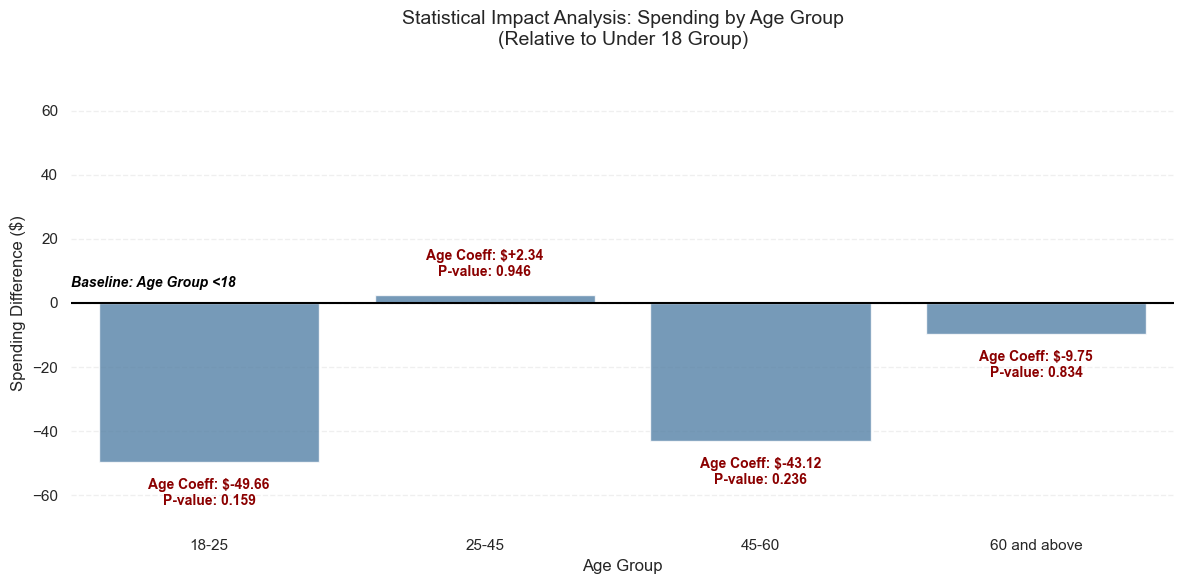

: 

In [ ]:
plt.figure(figsize=(12, 6))

impact_df = pd.DataFrame({
    'Group': [col.replace('Age Group_', '') for col in X_age_categorical.columns],
    'Coefficient': final_model_cat.coef_,
    'P_value': results_final_cat.pvalues.drop('const').values
})

ax = sns.barplot(x='Group', y='Coefficient', data=impact_df, color='steelblue', alpha=0.8)

plt.axhline(0, color='black', linestyle='-', linewidth=1.5)
plt.text(-0.5, 5, 'Baseline: Age Group <18', fontsize=10, fontweight='bold', color='black', style='italic')

margin = max(abs(impact_df['Coefficient'])) + 20
plt.ylim(-margin, margin)

for i, row in impact_df.iterrows():
    v = row['Coefficient']
    p = row['P_value']
        
    display_text = f"Age Coeff: ${v:+.2f}\nP-value: {p:.3f}"
    
    ax.text(i, v + (5 if v > 0 else -5), display_text, 
            ha='center', va='bottom' if v > 0 else 'top',
            fontsize=10, fontweight='bold', color='darkred' if p > 0.05 else 'darkgreen')

plt.title('Statistical Impact Analysis: Spending by Age Group\n(Relative to Under 18 Group)', fontsize=14, pad=25)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Spending Difference ($)', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.3)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()


# Final Report: Customer Age Impact on Spending

## 1. Objective

The goal of this analysis was to determine whether customer age influences the total purchase amount (**Gross Amount**) in our store. Understanding this relationship can help optimize marketing targeting and advertising strategy.

Specifically, we built several predictive models to evaluate how well **Age** explains customer spending.

---

## 2. Models Implemented

The following models were tested:

1. **Simple Linear Regression:** Treating Age as a continuous numeric variable.
2. **Categorical Linear Regression:** Using One-Hot Encoding for age groups.
3. **Random Forest Regressor:** To check for non-linear relationships.
4. **Multiple Linear Regression:** Including additional features (Gender, Payment Method).
5. **Validation Models (3.5 & 3.6):** Final check on refined, outlier-free data.

The final interpretation is based primarily on the model using **categorical age groups**, since age in the dataset is segmented rather than treated as a continuous yearly variable.

---

## 3. Model Comparison Table

| Model | R² | MAE | Intercept | Key Effects | Statistical Significance | Interpretation |
|-------|------|---------|------------|-------------|--------------------------|----------------|
| **3.1 Simple Linear Regression (Numeric Age)** | -0.00016122 | $1433.87 | 3020.00 | Age = 8.86 | p = 0.3073 (Not significant) | Age has no significant linear effect on spending |
| **3.2 Linear Regression (Categorical Age)** | 0.00008029 | $1433.68 | 3060.88 | 18–25: -49.66<br>25–45: 2.34<br>45–60: -43.12<br>60+: -9.75 | All p-values > 0.15 | No statistically significant differences between age groups |
| **3.3 Random Forest (Categorical Age)** | 0.00007517 | $1433.68 | Avg prediction: $3045.47 | Feature Importance:<br>18–25: 0.3708<br>25–45: 0.3368<br>60+: 0.1569<br>45–60: 0.1355 | Not applicable | Model confirms very low predictive power of age |
| **3.4 Multiple Linear Regression (All Features)** | -0.00059128 | $1433.99 | $2965.07 | Significant predictors:<br>PhonePe UPI: +129.60 (p=0.008)<br>Gender_Other: +44.70 (p=0.021) | Some predictors significant | Spending influenced by payment method & demographics, not age |
| **3.5 Final Numeric Validation** | 0.00000322 | $1438.57 | 3034.39 | Age = 3.24 | p = 0.6758 (Not significant) | Confirms extremely weak numeric age effect |
| **3.6 Final Categorical Validation** | 0.00020212 | $1438.41 | $3066.86 | 18–25: -49.66 (p=0.159)<br>25–45: 2.34 (p=0.946)<br>45–60: -43.12 (p=0.236)<br>60+: -9.75 (p=0.834) | All insignificant | Final confirmation: age groups do not meaningfully affect spending |

---

## 4. Key Research Findings

### **Q: If a customer "ages" by 10 years, how does their spending change?**
* **The Result:** According to our analysis, a 10-year increase in age does **not** result in any predictable or statistically significant change in spending.
* **Analysis of Transitions:** Even when a customer moves from one age category to the next (e.g., from the **18–25** group to the **25–45** group), the predicted difference in spending is only about **$52.00**.
* **Conclusion:** Given the high **p-values (0.15 - 0.94)**, these small differences are mathematically indistinguishable from zero. Therefore, "aging" by 10 years has no measurable impact on a customer's spending.

### **Q: Is the relationship strong, or does age barely affect spending?**
The relationship is **extremely weak** and practically non-existent:
1. **Statistical Insignificance:** All age group coefficients have p-values well above the 0.05 threshold.
2. **Near-Zero R²:** The **R² scores** indicate that Age explains almost 0% of the variation in spending.
3. **High Prediction Error:** The **MAE (~$1,438)** is massive compared to the tiny differences between age groups, proving that Age is just "noise" in this dataset.

---

## 5. Business Conclusion & Recommendations
* **De-prioritize Age Targeting:** Marketing budgets should not be allocated based on age, as customer spending is uniform across all demographics.
* **Focus on Behavioral Data:** **Model 3.4** identified that **Payment Method (PhonePe UPI)** is a much stronger and statistically significant predictor ($p=0.008$) than age.
* **Refine Data Collection:** To improve future predictions, the business should focus on collecting data on product preferences, purchase frequency, and loyalty status.

**Summary:** Age is a "noise" variable. Our models prove that age-based segmentation is ineffective for predicting transaction value in this store.